# MUSA 650 Homework 4: EuroSAT Land Use and Land Cover Classification using Machine Learning and Deep Learning

In this homework, we will explore land use and land cover (LULC) classification, comparing traditional machine learning and deep learning approaches.

## 1. Data Loading, Processing, and Exploration

1.1 Download EuroSAT Dataset

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from collections import Counter
import cv2
import random
from zipfile import ZipFile
!pip install rasterio
import rasterio

from google.colab import drive
drive.mount('/content/drive', force_remount=True)



Mounted at /content/drive


In [ ]:
# download EuroSAT dataset (RGB)
data_dir = "./eurosat_data"
transform = transforms.ToTensor()
dataset = datasets.EuroSAT(root=data_dir, download=True, transform=transform)

# check the classes
classes = dataset.classes
print("Classes:", classes)
print("Total samples:", len(dataset))

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total samples: 27000


1.2 label distribution and image display

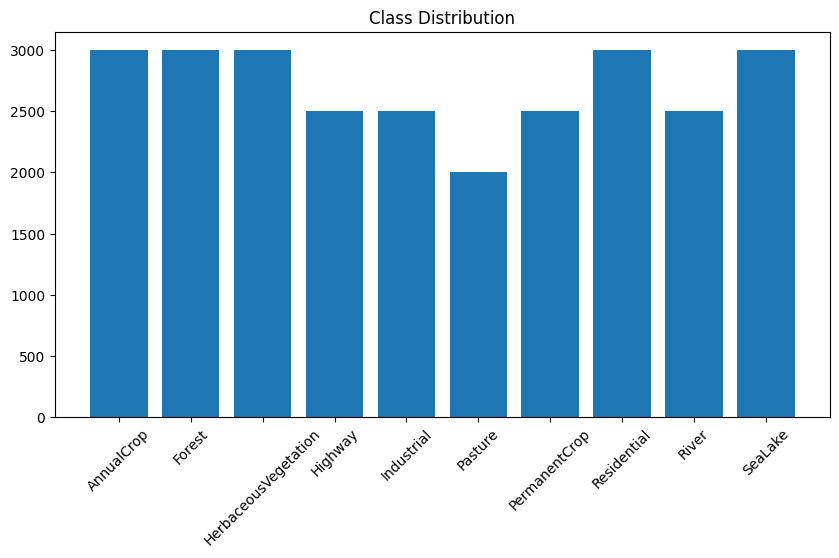

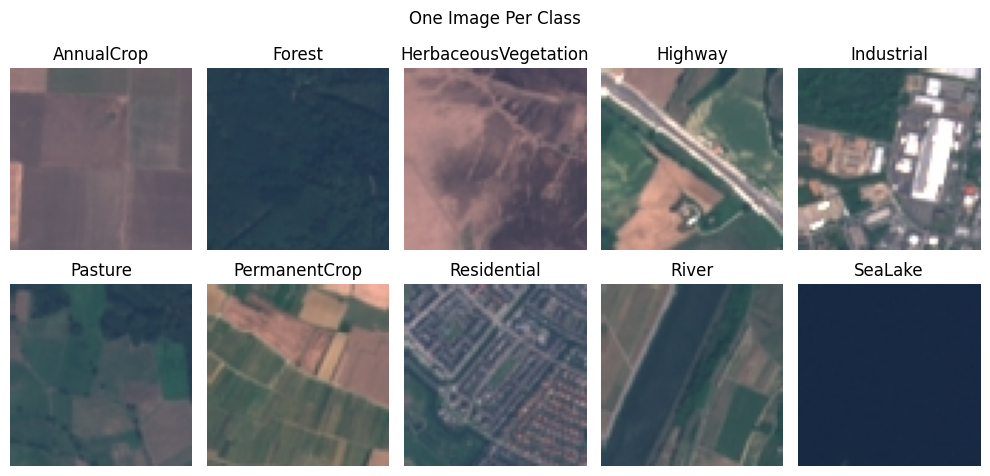

In [ ]:
# label distribution
labels = [dataset[i][1] for i in range(len(dataset))]
class_counts = Counter(labels)
plt.figure(figsize=(10, 5))
plt.bar(classes, [class_counts[i] for i in range(len(classes))])
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

# display one image per category
plt.figure(figsize=(10, 5))
shown_classes = set()
i = 0
while len(shown_classes) < 10:
    image, label = dataset[i]
    if label not in shown_classes:
        plt.subplot(2, 5, len(shown_classes)+1)
        plt.imshow(np.transpose(image.numpy(), (1, 2, 0)))
        plt.title(classes[label])
        plt.axis("off")
        shown_classes.add(label)
    i += 1
plt.suptitle("One Image Per Class")
plt.tight_layout()
plt.show()


1.3 Flatten Images into (n * p)

In [ ]:
data = []
labels = []

for img_tensor, label in dataset:
    img = img_tensor.numpy()
    flat_img = img.reshape(-1)  # Flatten (3x64x64 → 12288)
    data.append(flat_img)
    labels.append(label)

X = np.array(data)
y = np.array(labels)
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (27000, 12288)
y shape: (27000,)


1.4 Data Augmentation

Method: Randomly flip and rotate images

Augmented data size: 54,000

In [ ]:
from torchvision.transforms import functional as TF

def augment_image(img):

    if random.random() > 0.5:
        img = TF.hflip(img)
    angle = random.uniform(-25, 25)
    img = TF.rotate(img, angle)
    return img

augmented_images = []
augmented_labels = []

for i in range(len(dataset)):
    original_img, label = dataset[i]
    aug_img = augment_image(original_img)
    aug_flat = aug_img.numpy().reshape(-1)
    augmented_images.append(aug_flat)
    augmented_labels.append(label)

# Merging original and augmented data
X_aug = np.concatenate([X, np.array(augmented_images)], axis=0)
y_aug = np.concatenate([y, np.array(augmented_labels)], axis=0)
print("New dataset size after augmentation:", X_aug.shape[0])



New dataset size after augmentation: 54000


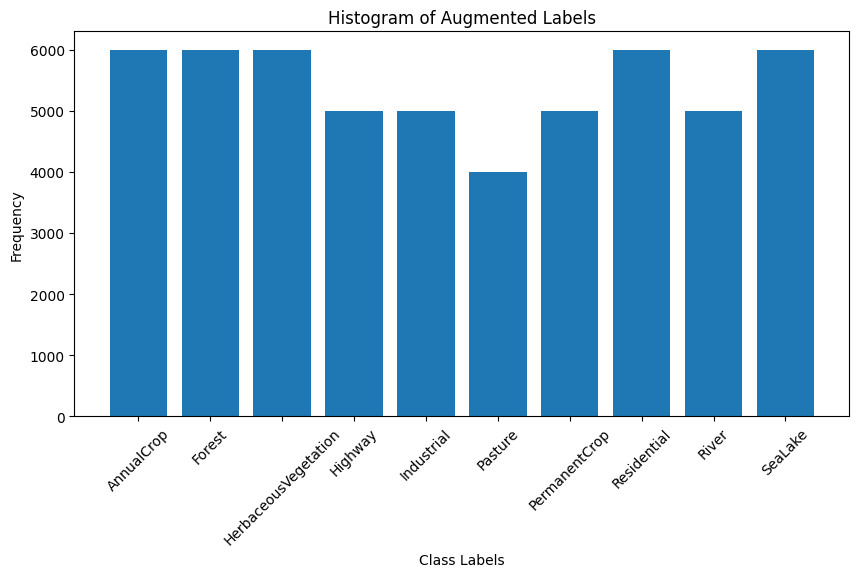

In [ ]:
# histogram of augmented labels
unique_classes, counts = np.unique(y_aug, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(unique_classes, counts, width=0.8)
plt.xticks(ticks=unique_classes, labels=classes, rotation=45)
plt.xlabel("Class Labels")
plt.ylabel("Frequency")
plt.title("Histogram of Augmented Labels")
plt.show()



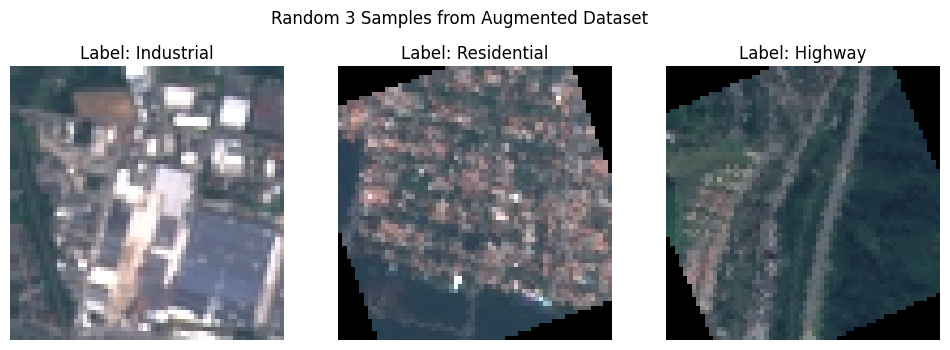

In [ ]:
# Random 3 Samples from Augmented Dataset
random_indices = random.sample(range(X_aug.shape[0]), 3)

plt.figure(figsize=(12, 4))
for i, idx in enumerate(random_indices):
    img = X_aug[idx].reshape(3, 64, 64)
    img = np.transpose(img, (1, 2, 0))

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Label: {classes[y_aug[idx]]}")

plt.suptitle("Random 3 Samples from Augmented Dataset")
plt.show()


1.5 Stratified Train/Test Split (60% / 40%)

In [ ]:
# RGB train and test dataset (including all classes)
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.4, random_state=650, stratify=y_aug)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (32400, 12288)
Test set size: (21600, 12288)


1.5 Covert to Grayscale

In [ ]:
def to_grayscale(flat_img):
    rgb_img = flat_img.reshape(3, 64, 64).transpose(1, 2, 0)  # (64, 64, 3)
    gray = cv2.cvtColor((rgb_img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    return gray.flatten() / 255.0

# gray train and test dataset (including all classes)
X_gray = np.array([to_grayscale(img) for img in X_aug])
X_train_gray, X_test_gray, y_train_gray, y_test_gray = train_test_split(
    X_gray, y_aug, test_size=0.4, random_state=650, stratify=y_aug)

print("Training set size:", X_train_gray.shape)
print("Test set size:", X_test_gray.shape)


Training set size: (32400, 4096)
Test set size: (21600, 4096)


## 2. Traditional Machine Learning
- use gray data

### 2.1 extract the 3 classes (froest, industry and residential)

In [ ]:
# Tag index mapping
label_map = { 'Forest': 0, 'Residential': 1, 'Industrial': 2 }
original_class_indices = {cls: classes.index(cls) for cls in label_map.keys()}

# Only extract samples of three categories
selected_indices = [i for i, y in enumerate(y_aug) if y in original_class_indices.values()]
X_gray_selected = X_gray[selected_indices]
y_selected = np.array([list(original_class_indices.values()).index(y) for y in y_aug[selected_indices]])

# train-test split (Keep stratified sampling)
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_gray_selected, y_selected, test_size=0.4, random_state=650, stratify=y_selected)

print("Selected classes:", list(label_map.keys()))
print("------------")
print("training and testing dataset size of the selected classes:")
print("X_train shape:", X_train_sel.shape)
print("y_train shape:", y_train_sel.shape)
print("X_test shape:", X_test_sel.shape)
print("y_test shape:", y_test_sel.shape)

Selected classes: ['Forest', 'Residential', 'Industrial']
------------
training and testing dataset size of the selected classes:
X_train shape: (10200, 4096)
y_train shape: (10200,)
X_test shape: (6800, 4096)
y_test shape: (6800,)


### 2.2 Binary SVM Classifiers

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Residential vs Industrial Accuracy: 0.4982, AUC: 0.5419


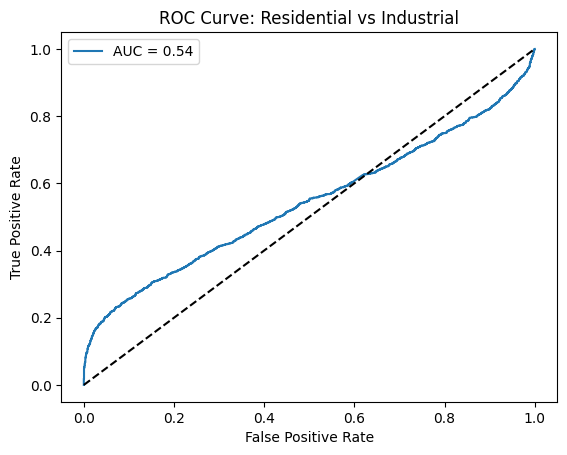

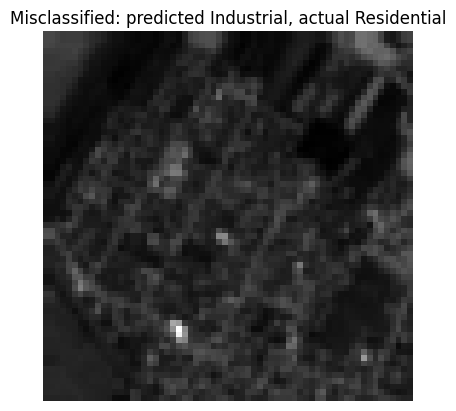

Forest vs Industrial Accuracy: 0.9984, AUC: 1.0000


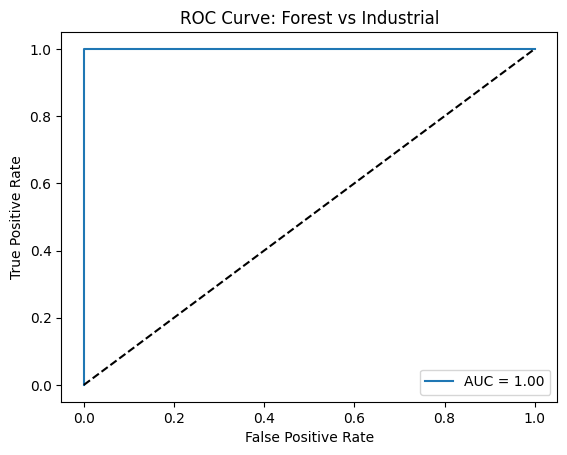

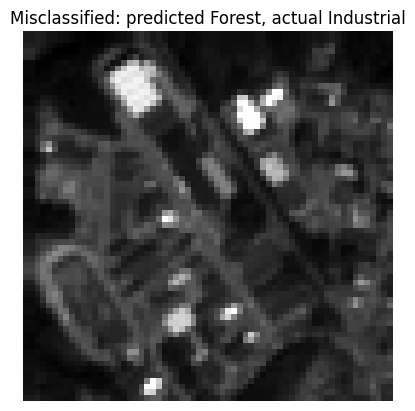

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Forest vs Residential Accuracy: 0.9677, AUC: 0.9971


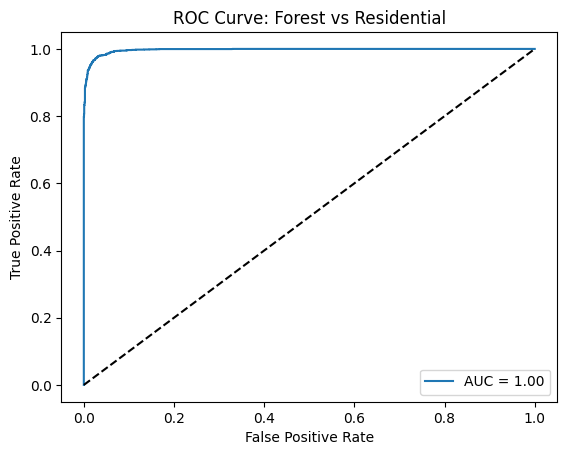

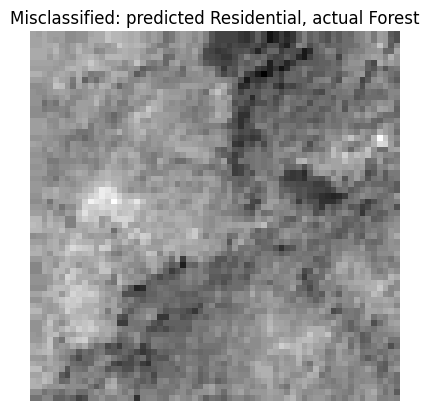

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

def binary_svm(X_train, y_train, X_test, y_test, class_pair, label_names):
    # choose subset
    idx_train = np.isin(y_train, class_pair)
    idx_test = np.isin(y_test, class_pair)

    X_train_bin = X_train[idx_train]
    y_train_bin = y_train[idx_train]
    X_test_bin = X_test[idx_test]
    y_test_bin = y_test[idx_test]

    # turn label into 0 and 1
    y_train_bin = (y_train_bin == class_pair[1]).astype(int)
    y_test_bin = (y_test_bin == class_pair[1]).astype(int)


    # train model
    clf = SVC(kernel='linear', probability=True, max_iter=2000)
    clf.fit(X_train_bin, y_train_bin)

    # Prediction and evaluation
    y_pred = clf.predict(X_test_bin)
    y_prob = clf.predict_proba(X_test_bin)[:,1]
    acc = accuracy_score(y_test_bin, y_pred)
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
    auc_score = auc(fpr, tpr)

    # print Accuracy and AUC
    print(f"{label_names[class_pair[0]]} vs {label_names[class_pair[1]]} Accuracy: {acc:.4f}, AUC: {auc_score:.4f}")

    # plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {label_names[class_pair[0]]} vs {label_names[class_pair[1]]}")
    plt.legend()
    plt.show()

    # Find the wrong prediction samples and display them
    misclassified = X_test_bin[(y_pred != y_test_bin)]
    if len(misclassified) > 0:
        idx = np.random.choice(len(misclassified))
        img = misclassified[idx].reshape(64, 64)
        true_label = label_names[class_pair[y_test_bin[(y_pred != y_test_bin)][idx]]]
        pred_label = label_names[class_pair[y_pred[(y_pred != y_test_bin)][idx]]]
        plt.imshow(img, cmap="gray")
        plt.title(f"Misclassified: predicted {pred_label}, actual {true_label}")
        plt.axis("off")
        plt.show()

# Tag Name Index
label_names = {0: "Forest", 1: "Residential", 2: "Industrial"}

# Three groups of binary categories
binary_svm(X_train_sel, y_train_sel, X_test_sel, y_test_sel, (1,2), label_names)
binary_svm(X_train_sel, y_train_sel, X_test_sel, y_test_sel, (0,2), label_names)
binary_svm(X_train_sel, y_train_sel, X_test_sel, y_test_sel, (0,1), label_names)


### 2.3 Multiclass, Majority-Vote Support Vector Machine

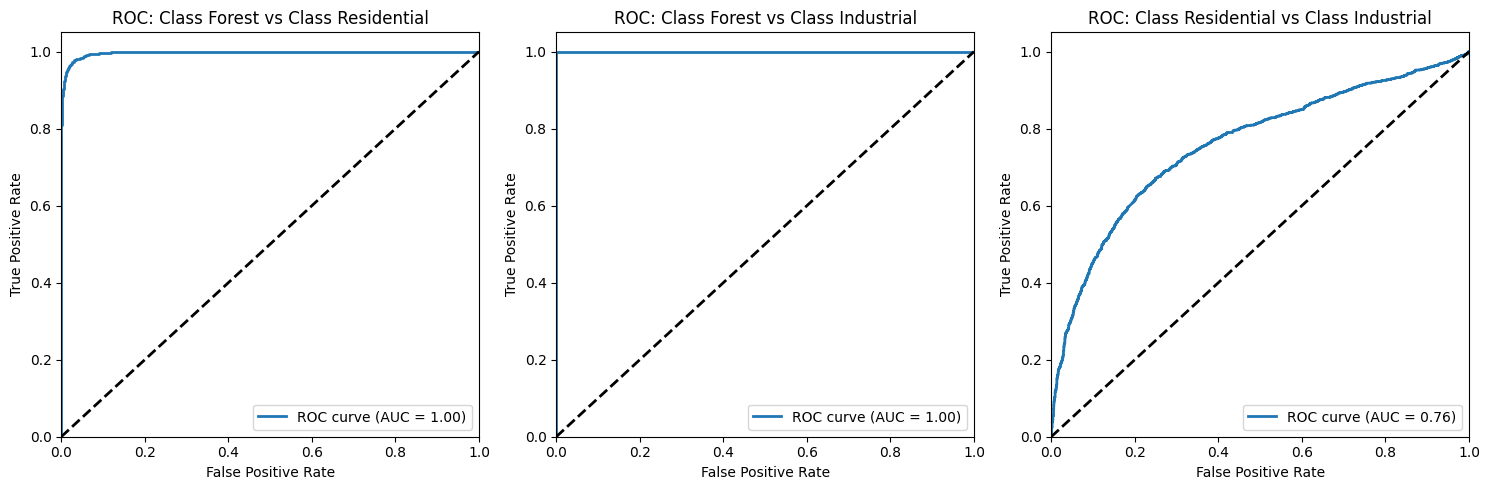

Multiclass SVM Accuracy (Majority Vote): 0.7970588235294118


<Figure size 800x600 with 0 Axes>

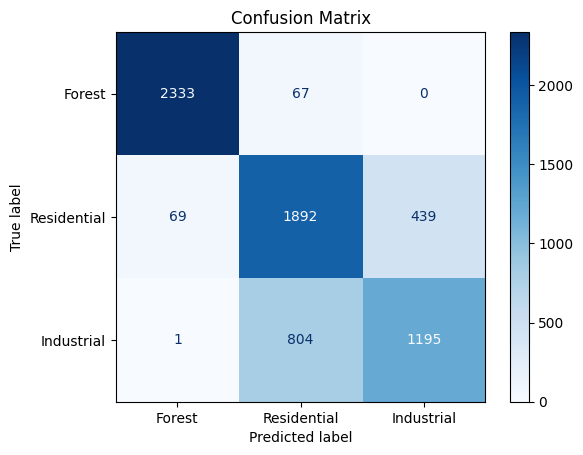

Class Forest:
  Precision: 0.9709
  Recall: 0.9721
Class Residential:
  Precision: 0.6848
  Recall: 0.7883
Class Industrial:
  Precision: 0.7313
  Recall: 0.5975


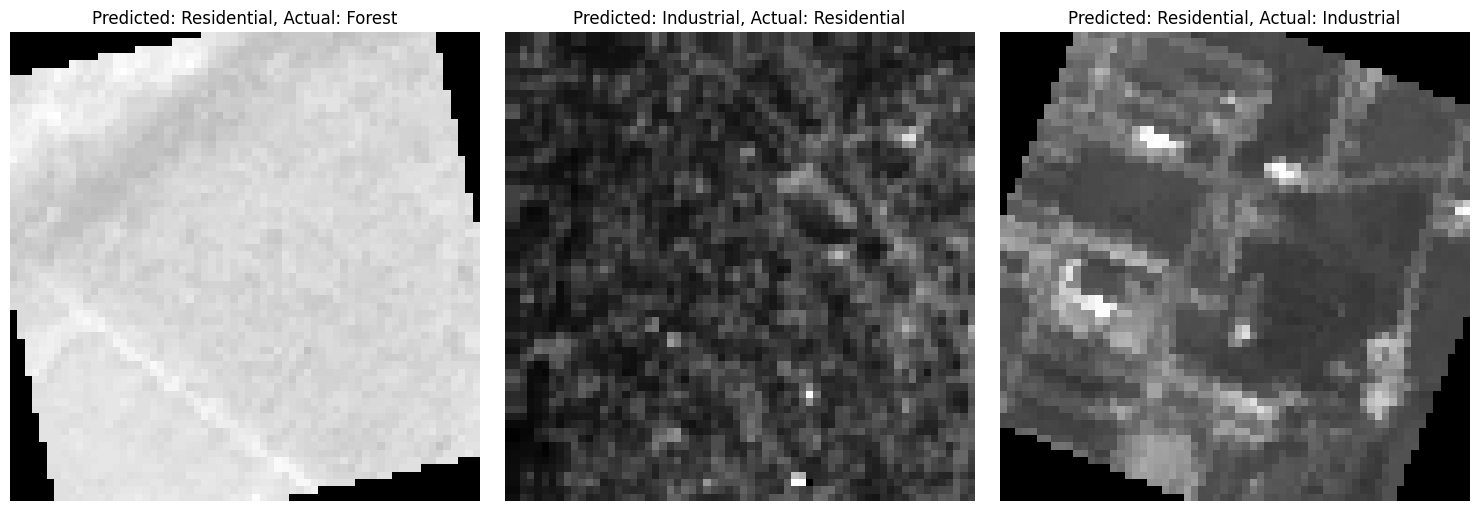

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import random
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_models = {}
pairs = [(0, 1), (0, 2), (1, 2)]
for a, b in pairs:
    idx = np.isin(y_train_sel, [a, b])
    clf = SVC(kernel='linear', probability=True)
    clf.fit(X_train_sel[idx], (y_train_sel[idx] == b).astype(int))
    svm_models[(a, b)] = clf

# Draw the ROC curve between each two classes and calculate the AUC
plt.figure(figsize=(15, 5))
for i, (a, b) in enumerate(pairs):
    plt.subplot(1, 3, i+1)

    # Select samples in the test set that belong to the current two categories
    idx_test = np.isin(y_test_sel, [a, b])
    X_test_pair = X_test_sel[idx_test]
    y_test_pair = (y_test_sel[idx_test] == b).astype(int)

    # predict probability
    y_score = svm_models[(a, b)].predict_proba(X_test_pair)[:, 1]

    # calculate ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test_pair, y_score)
    roc_auc = auc(fpr, tpr)

    # plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC: Class {label_names[a]} vs Class {label_names[b]}')
    plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# majority vote prediction
def majority_vote(models, X):
    votes = np.zeros((len(X), 3))
    for (a, b), clf in models.items():
        prob = clf.predict_proba(X)
        pred = (prob[:,1] > 0.5).astype(int)
        pred_labels = np.where(pred == 1, b, a)
        for i, lbl in enumerate(pred_labels):
            votes[i, lbl] += 1
    final_preds = np.argmax(votes, axis=1)
    return final_preds

y_pred_mv = majority_vote(svm_models, X_test_sel)
acc_mv = accuracy_score(y_test_sel, y_pred_mv)
print("Multiclass SVM Accuracy (Majority Vote):", acc_mv)

# plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_sel, y_pred_mv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_names[i] for i in range(3)])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# calculate precision and recall for each class
for i in range(3):
    class_indices = (y_test_sel == i)
    tp = np.sum((y_test_sel == i) & (y_pred_mv == i))
    fp = np.sum((y_test_sel != i) & (y_pred_mv == i))
    fn = np.sum((y_test_sel == i) & (y_pred_mv != i))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"Class {label_names[i]}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")

# display misclassified samples
plt.figure(figsize=(15, 5))
for j, cls in enumerate([0, 1, 2]):
    wrong = np.where((y_test_sel == cls) & (y_pred_mv != cls))[0]
    if len(wrong) > 0:
        plt.subplot(1, 3, j+1)
        idx = random.choice(wrong)
        img = X_test_sel[idx].reshape(64, 64)
        plt.imshow(img, cmap="gray")
        plt.title(f"Predicted: {label_names[y_pred_mv[idx]]}, Actual: {label_names[cls]}")
        plt.axis("off")
plt.tight_layout()
plt.show()

### 2.4 Multiple Classes Random Forest

Random Forest Accuracy: 0.9213235294117647


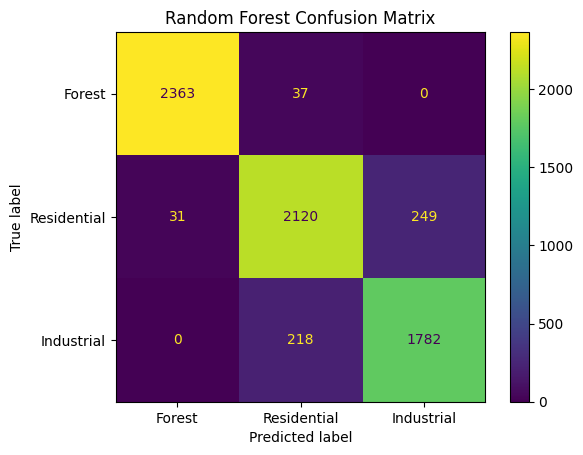

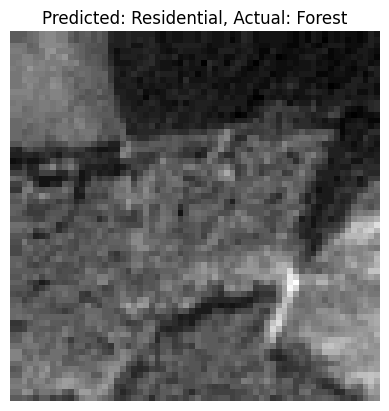

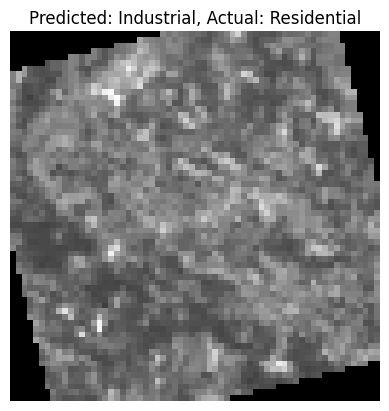

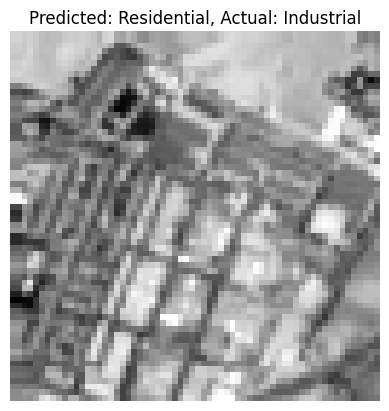

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# train random forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sel, y_train_sel)

# prediction and evaluation
y_pred_rf = rf.predict(X_test_sel)
acc_rf = accuracy_score(y_test_sel, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

# confusion matrix
cm = confusion_matrix(y_test_sel, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label_names.values()))
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# display misclassified samples
for cls in [0, 1, 2]:
    wrong = np.where((y_test_sel == cls) & (y_pred_rf != cls))[0]
    if len(wrong) > 0:
        idx = random.choice(wrong)
        img = X_test_sel[idx].reshape(64, 64)
        plt.imshow(img, cmap="gray")
        plt.title(f"Predicted: {label_names[y_pred_rf[idx]]}, Actual: {label_names[cls]}")
        plt.axis("off")
        plt.show()


## 3. Deep Learning
- use all classes

### 3.1 Greyscale Images



#### 3.1.1 Model One - Single fully connected layer

Accuracy on test data: 0.2373

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1308 - loss: 2.4002 - val_accuracy: 0.1636 - val_loss: 2.3368
Epoch 2/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1794 - loss: 2.2659 - val_accuracy: 0.2270 - val_loss: 2.1795
Epoch 3/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2080 - loss: 2.2377 - val_accuracy: 0.1461 - val_loss: 2.3502
Epoch 4/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2251 - loss: 2.2017 - val_accuracy: 0.2557 - val_loss: 2.1651
Epoch 5/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2422 - loss: 2.1660 - val_accuracy: 0.2097 - val_loss: 2.1906
Epoch 6/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2502 - loss: 2.1434 - val_accuracy: 0.2270 - val_loss: 2.1296
Epoch 7/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2473 - loss: 2.1000 - val_accuracy: 0.2226 - val_loss: 2.0829
Epoch 8/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2602 - loss: 2.0678 - 

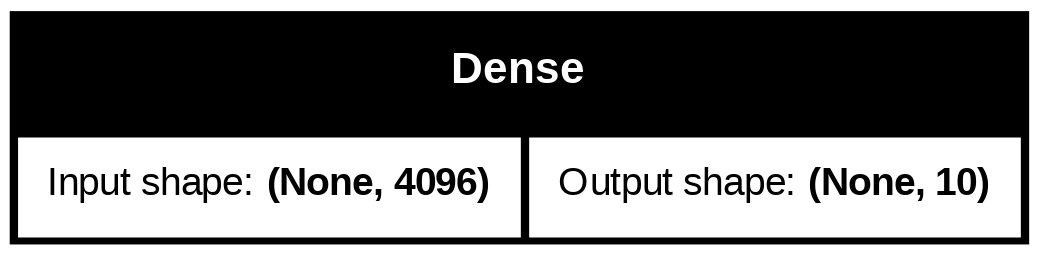

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import LabelEncoder

# one-hot encoding
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

# define model
model1 = Sequential([
    Dense(10, input_shape=(4096,), activation='softmax')  # 直接使用展平后的形状
])

# train model
model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history1 = model1.fit(X_train_gray, y_train_enc, epochs=10, batch_size=32, validation_data=(X_test_gray, y_test_enc))

# calculate accuracy
test_loss, test_acc = model1.evaluate(X_test_gray, y_test_enc)
print(f"Model 1 Test Accuracy: {test_acc:.4f}")

# plot model structure
plot_model(model1, to_file='model1_architecture.png', show_shapes=True)


675/675 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


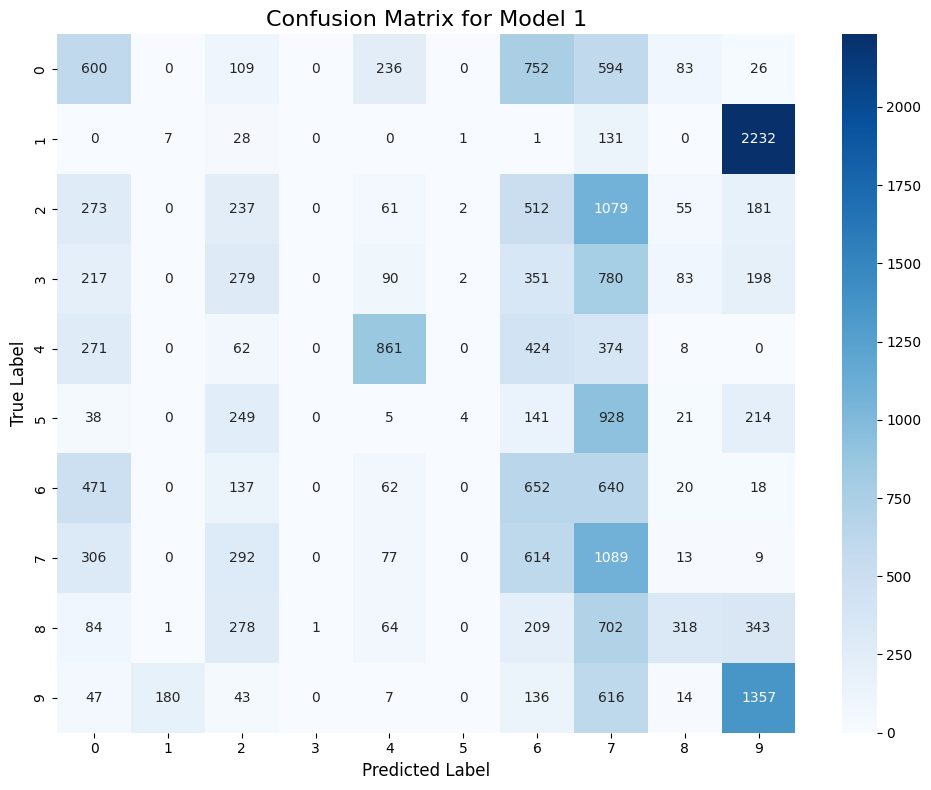

In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model1.predict(X_test_gray)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_enc, y_pred_classes)

plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.title('Confusion Matrix for Model 1', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

#### 3.1.2 Model Two - Add a fully connected hidden layer

Accuracy on test data: 0.3773

After adding an additional fully connected hidden layer, the classification accuracy on the test data improved from approximately 0.2373 to 0.3773. This shows that the deeper model was able to learn more complex patterns from the data and achieved better performance compared to the shallower model.

Additional hidden layers can improve model accuracy because they allow the network to capture more complex, hierarchical features of the data. Each extra layer can learn increasingly abstract representations, which can lead to better generalization if designed and trained properly.
However, adding more layers can also worsen accuracy if not handled carefully. Deeper networks are harder to train: they are more prone to overfitting and can suffer from vanishing or exploding gradients during backpropagation.

In [ ]:
model2 = Sequential([
    Dense(512, input_shape=(4096,), activation='relu'),  # First hidden layer with 512 neurons and ReLU activation
    Dense(256, activation='relu'),  # Second hidden layer with 256 neurons and ReLU activation
    Dense(10, activation='softmax')  # Output layer with 10 classes using softmax activation
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history2 = model2.fit(X_train_gray, y_train_enc, epochs=10, batch_size=32, validation_data=(X_test_gray, y_test_enc))

test_loss, test_acc = model2.evaluate(X_test_gray, y_test_enc)
print(f"Model 2 Test Accuracy: {test_acc:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.1655 - loss: 2.2483 - val_accuracy: 0.2854 - val_loss: 1.8813
Epoch 2/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.2829 - loss: 1.8489 - val_accuracy: 0.3187 - val_loss: 1.8171
Epoch 3/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.3044 - loss: 1.7890 - val_accuracy: 0.3161 - val_loss: 1.7427
Epoch 4/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.3252 - loss: 1.7468 - val_accuracy: 0.3294 - val_loss: 1.7124
Epoch 5/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.3542 - loss: 1.6757 - val_accuracy: 0.3365 - val_loss: 1.7243
Epoch 6/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.3654 - loss: 1.6545 - val_accuracy: 0.3832 - val_loss: 1.6706
Epoch 7/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.3612 - loss: 1.6538 - val_accuracy: 0.3242 - val_loss: 1.7469
Epoch 8/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.3675 -

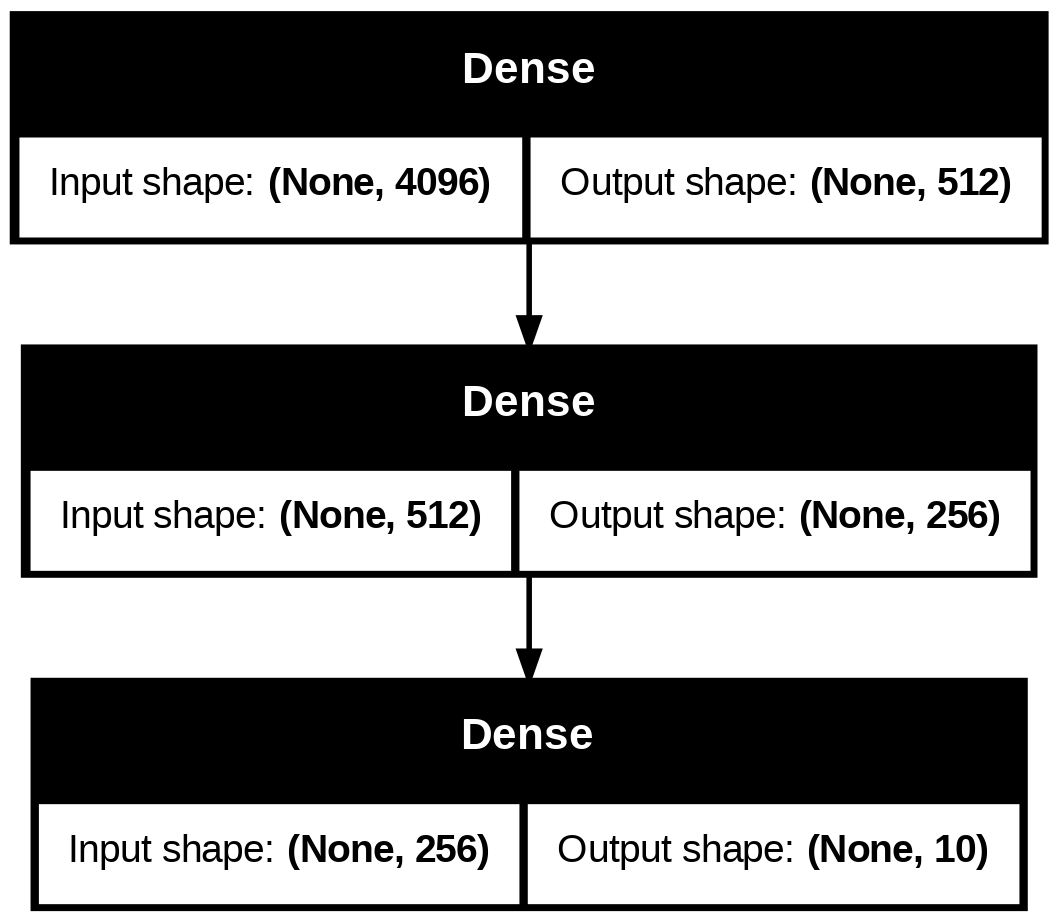

In [ ]:
plot_model(model2, to_file='model2_architecture.png', show_shapes=True)

675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


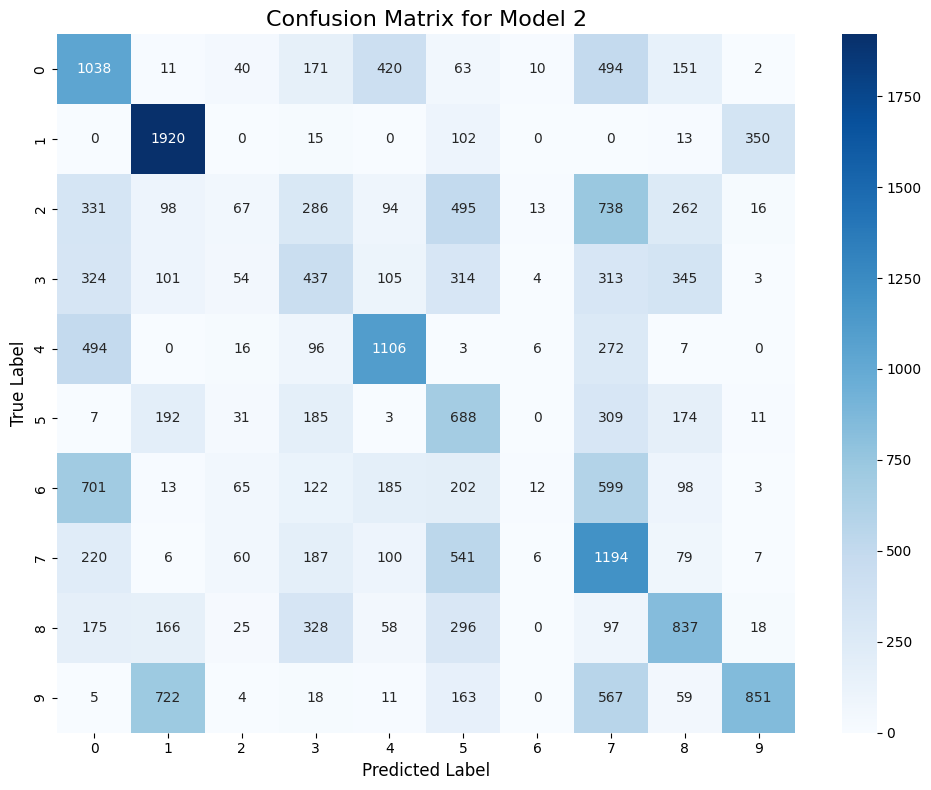

In [ ]:
# confusion matrix
y_pred = model2.predict(X_test_gray)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_enc, y_pred_classes)

plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.title('Confusion Matrix for Model 2', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

#### 3.1.3 Model Three - Add two hidden layers and dropout layers on model 2

Accuracy on test data: 0.1475

After adding two additional fully connected hidden layers and applying dropout, the model's test accuracy dropped significantly from 0.3773 to 0.1475. This suggests that the model may have become too complex relative to the size or nature of the training data, and the dropout may have introduced too much randomness during training, preventing the model from learning effectively.

Dropout is a regularization technique where, during each training step, a random subset of neurons is temporarily "dropped" (set to zero) with a certain probability. This prevents neurons from co-adapting too much, forces the network to be more robust, and helps reduce overfitting, especially when training deep networks on small datasets.

However, if the dataset is already small, the model is not overfitting yet, or the dropout rate is too high, applying dropout can make training harder and hurt performance, as the model might struggle to learn meaningful patterns. In such cases, using a smaller dropout rate or even disabling dropout might be better.

Epoch 1/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.1407 - loss: 2.3061 - val_accuracy: 0.1808 - val_loss: 2.1622
Epoch 2/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.1868 - loss: 2.0724 - val_accuracy: 0.1529 - val_loss: 2.5820
Epoch 3/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.2112 - loss: 2.0128 - val_accuracy: 0.1144 - val_loss: 2.5874
Epoch 4/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.2241 - loss: 1.9969 - val_accuracy: 0.1489 - val_loss: 2.4593
Epoch 5/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.2274 - loss: 1.9929 - val_accuracy: 0.1293 - val_loss: 2.9529
Epoch 6/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.2282 - loss: 1.9827 - val_accuracy: 0.1413 - val_loss: 2.5911
Epoch 7/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.2337 - loss: 1.9718 - val_accuracy: 0.1508 - val_loss: 2.6151
Epoch 8/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.2342 -

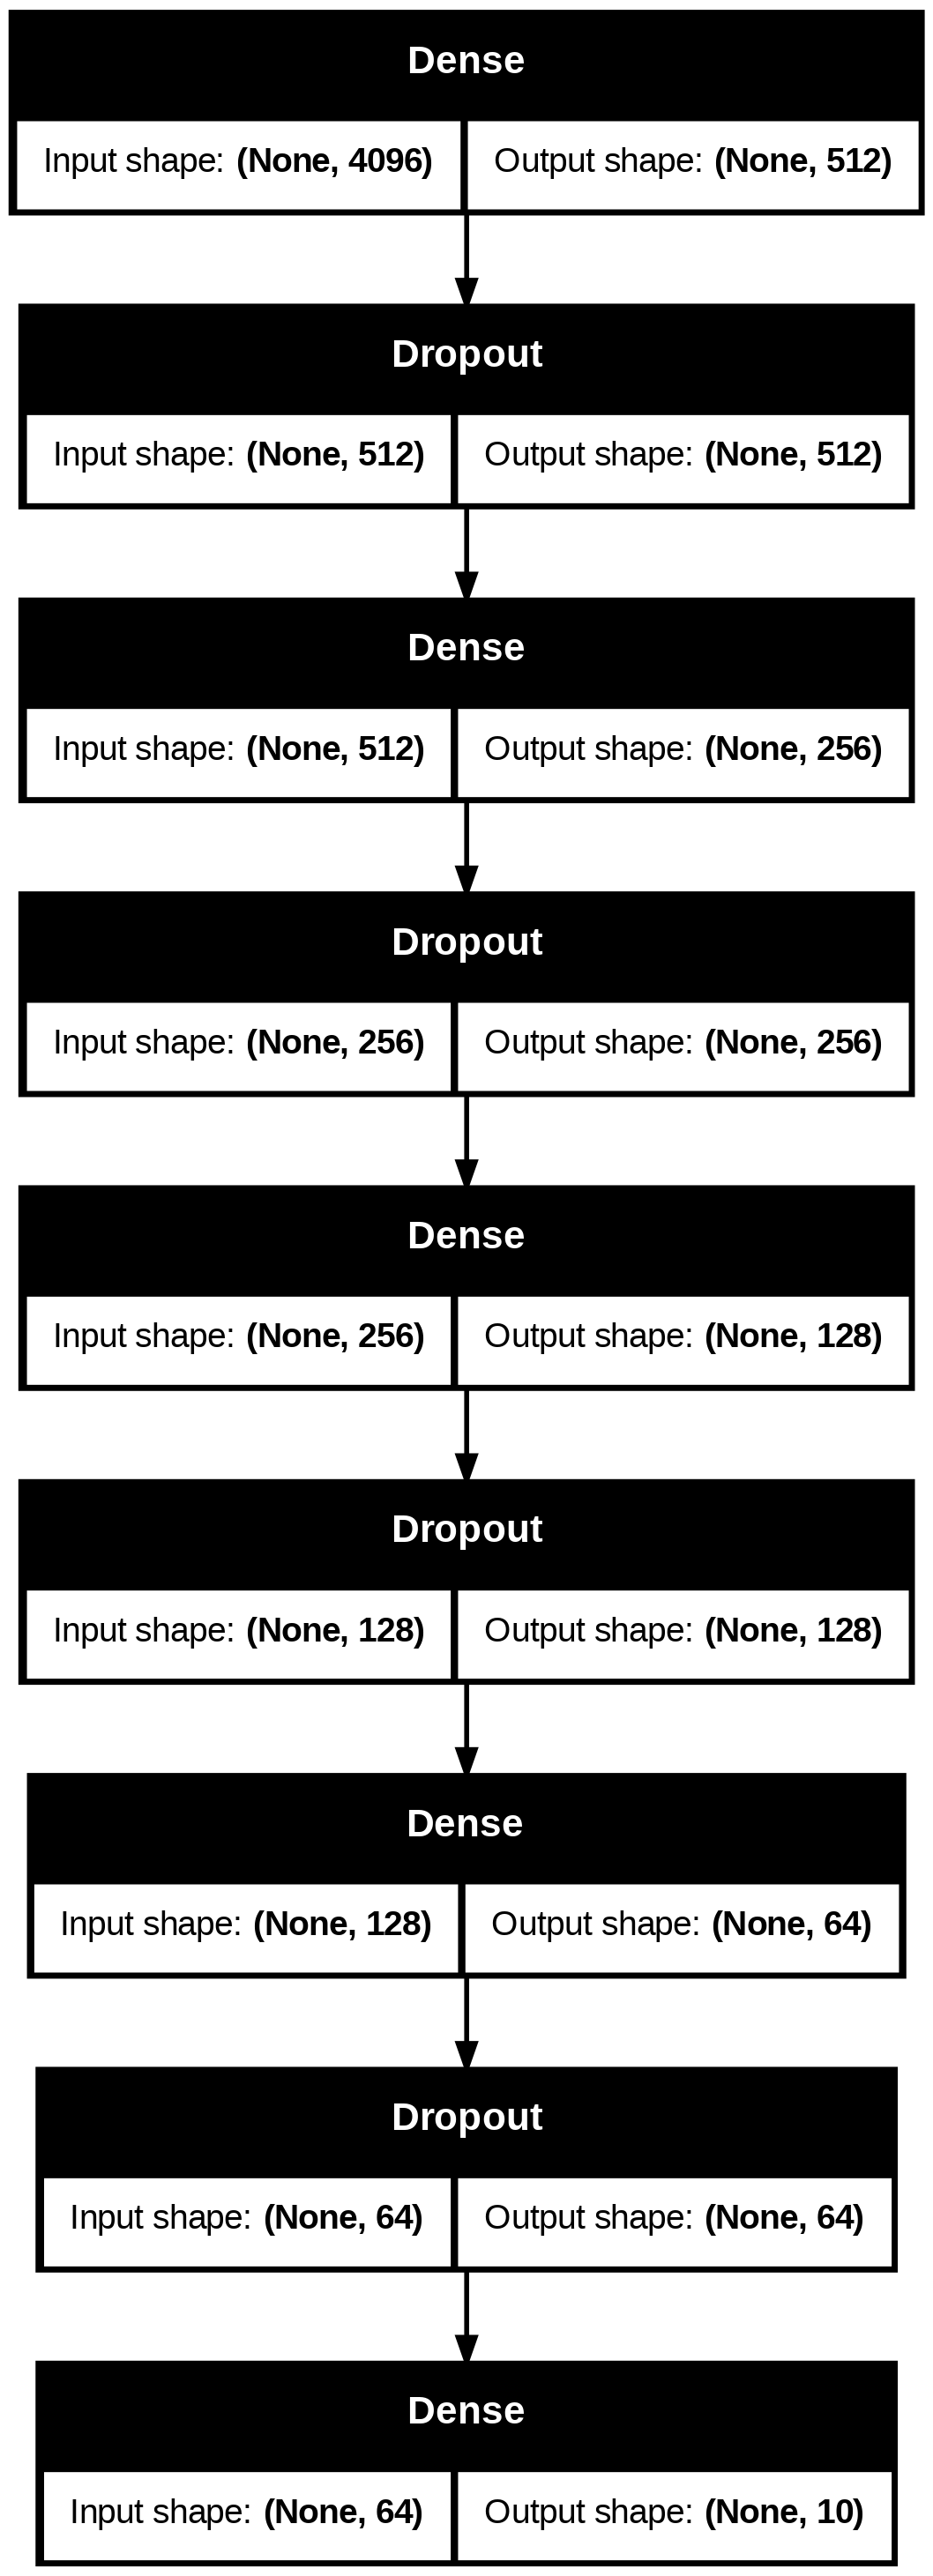

In [ ]:
from tensorflow.keras.layers import Dropout  # 导入 Dropout
# Model Three: Add two more hidden layers and dropout layers
model3 = Sequential([
    Dense(512, input_shape=(4096,), activation='relu'),  # First hidden layer with 512 neurons
    Dropout(0.3),  # Dropout with 30% dropout rate
    Dense(256, activation='relu'),  # Second hidden layer with 256 neurons
    Dropout(0.3),  # Dropout with 30% dropout rate
    Dense(128, activation='relu'),  # Third hidden layer with 128 neurons
    Dropout(0.3),  # Dropout with 30% dropout rate
    Dense(64, activation='relu'),  # Fourth hidden layer with 64 neurons
    Dropout(0.3),  # Dropout with 30% dropout rate
    Dense(10, activation='softmax')  # Output layer with 10 classes using softmax activation
])

model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history3 = model3.fit(X_train_gray, y_train_enc, epochs=10, batch_size=32, validation_data=(X_test_gray, y_test_enc))

test_loss, test_acc = model3.evaluate(X_test_gray, y_test_enc)
print(f"Model 3 Test Accuracy: {test_acc:.4f}")

plot_model(model3, to_file='model3_architecture.png', show_shapes=True)

675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


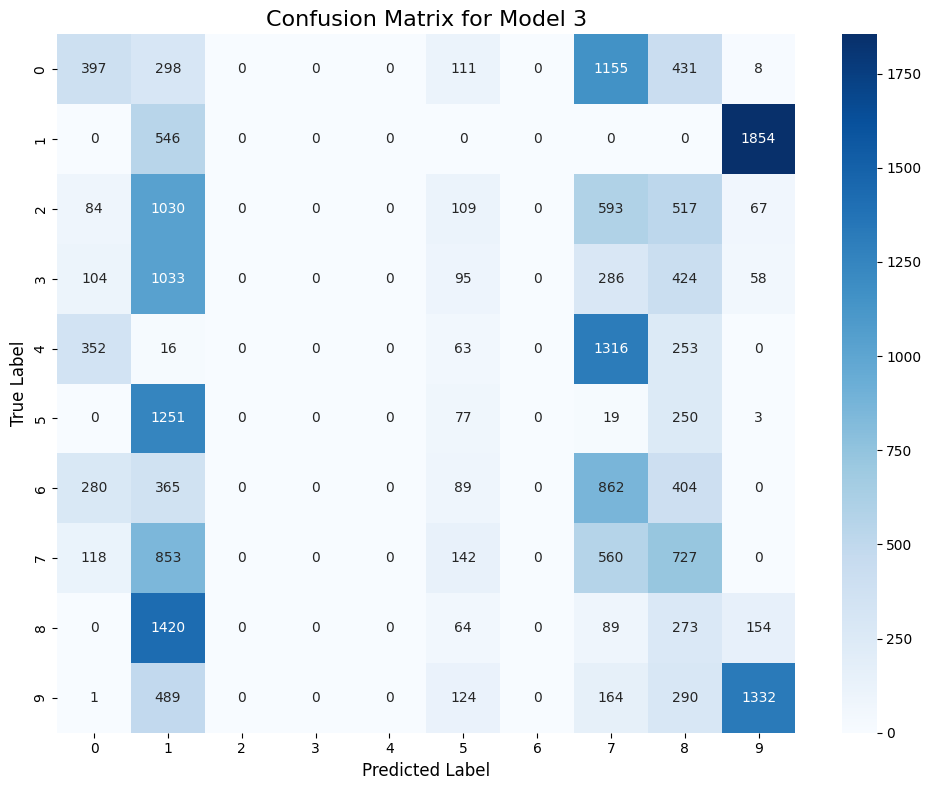

In [ ]:
# confusion matrix
y_pred = model3.predict(X_test_gray)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_enc, y_pred_classes)

plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.title('Confusion Matrix for Model 3', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()


#### 3.1.4 Model Comparison among model1-3

**parameters and margin**

Model 1 (Simple): 40,970 parameters

Model 2 (2 Hidden Layers): 2,231,562 parameters

Model 3 (4 Hidden Layers + Dropout): 2,270,794 parameters

Model 3 had the most parameters, about 40,000 more than Model 2, and vastly more than Model 1.



**Which model was the "best"? Why?**

Model 2 was the best-performing model, achieving the highest test accuracy of 0.3773. Although Model 3 had the most parameters, its accuracy dropped significantly to 0.1475, likely due to excessive model complexity, or the impact of added dropout layers. Model 1 had the least complexity but also the lowest accuracy of 0.2373.
Thus, Model 2 struck a better balance between complexity and generalization for this dataset.

**For each model, what is the impact of increasing the number of training epochs?**

Model 1: Training accuracy and validation accuracy increased slightly, but the model had limited capacity to learn complex patterns, leading to modest gains.

Model 2: Both training and validation accuracy steadily improved across epochs. More epochs helped the model learn better representations without severe overfitting.

Model 3: Training accuracy improved, but validation accuracy remained low and unstable. Longer training led to worsening generalization, even with dropout layers — a sign that the model was too complex for the available data.

In [ ]:
models = [model1, model2, model3]
model_names = ['Model 1', 'Model 2', 'Model 3']

# Calculate the number of parameters for each model
for i, model in enumerate(models):
    params = model.count_params()
    print(f"{model_names[i]} number of parameters: {params}")


Model 1 number of parameters: 40970
Model 2 number of parameters: 2231562
Model 3 number of parameters: 2270794


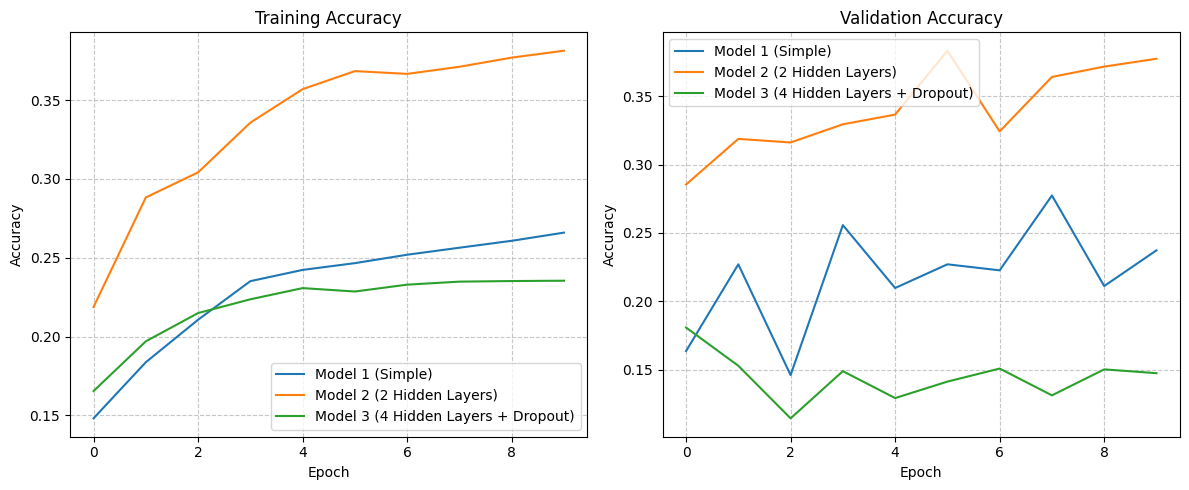

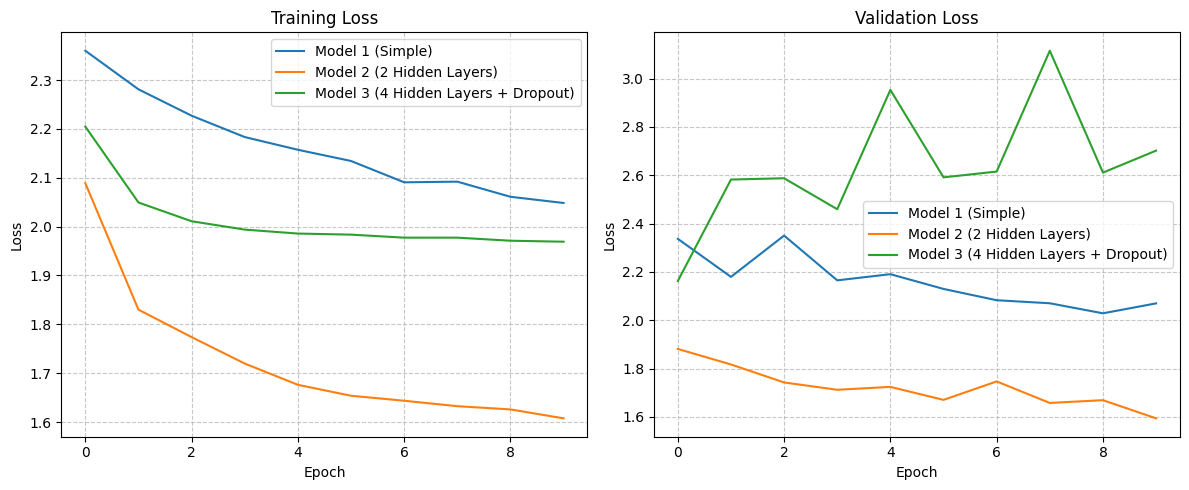

675/675 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2342 - loss: 2.0724
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3743 - loss: 1.5967
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1462 - loss: 2.7036


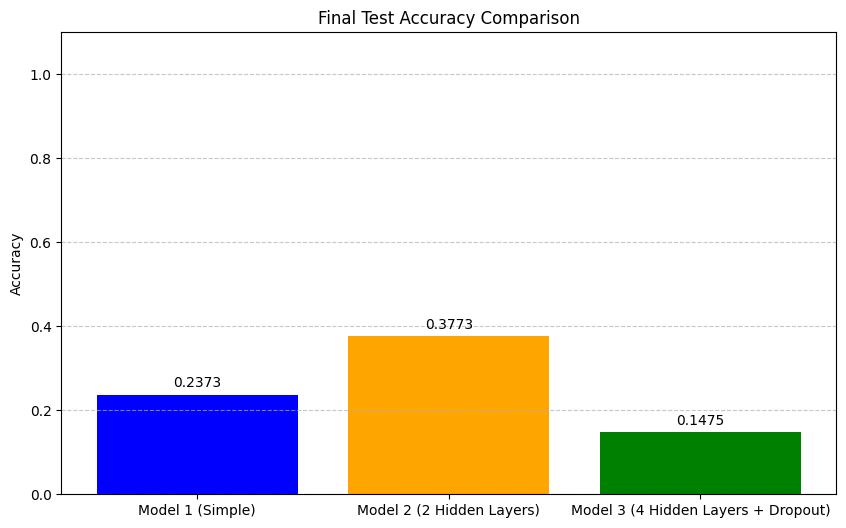

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from itertools import cycle

# Create a chart to compare the training and validation accuracy of the three models
plt.figure(figsize=(12, 5))

# Plotting training accuracy
plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Model 1 (Simple)')
plt.plot(history2.history['accuracy'], label='Model 2 (2 Hidden Layers)')
plt.plot(history3.history['accuracy'], label='Model 3 (4 Hidden Layers + Dropout)')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plotting the validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history1.history['val_accuracy'], label='Model 1 (Simple)')
plt.plot(history2.history['val_accuracy'], label='Model 2 (2 Hidden Layers)')
plt.plot(history3.history['val_accuracy'], label='Model 3 (4 Hidden Layers + Dropout)')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Plotting training and validation losses
plt.figure(figsize=(12, 5))

# Plotting the training loss
plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'], label='Model 1 (Simple)')
plt.plot(history2.history['loss'], label='Model 2 (2 Hidden Layers)')
plt.plot(history3.history['loss'], label='Model 3 (4 Hidden Layers + Dropout)')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plotting the validation loss
plt.subplot(1, 2, 2)
plt.plot(history1.history['val_loss'], label='Model 1 (Simple)')
plt.plot(history2.history['val_loss'], label='Model 2 (2 Hidden Layers)')
plt.plot(history3.history['val_loss'], label='Model 3 (4 Hidden Layers + Dropout)')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Bar chart comparing final test accuracy
def plot_final_accuracy(models_accuracy, model_names):
    plt.figure(figsize=(10, 6))
    bars = plt.bar(model_names, models_accuracy, color=['blue', 'orange', 'green'])

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.4f}', ha='center', va='bottom')

    plt.title('Final Test Accuracy Comparison')
    plt.ylim(0, 1.1)
    plt.ylabel('Accuracy')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Get the accuracy from the evaluation results of each model
model1_acc = model1.evaluate(X_test_gray, y_test_enc)[1]
model2_acc = model2.evaluate(X_test_gray, y_test_enc)[1]
model3_acc = model3.evaluate(X_test_gray, y_test_enc)[1]

# Draw the final accuracy comparison chart
model_accuracies = [model1_acc, model2_acc, model3_acc]
model_names = ['Model 1 (Simple)', 'Model 2 (2 Hidden Layers)', 'Model 3 (4 Hidden Layers + Dropout)']
plot_final_accuracy(model_accuracies, model_names)

### 3.2 RGB Images

#### 3.2.1 Model Four - CNN

I implemented a CNN with Conv2D, MaxPooling2D, Dropout, Flatten, and Dense layers. The network architecture was visualized.

The CNN achieved a test accuracy of **0.8282**, which is much higher than all previous models. Therefore, the CNN model was the best because it achieved the highest accuracy by effectively capturing spatial patterns in the image data.

The CNN model trained slower compared to the fully connected models due to the heavier computational cost of convolution and pooling operations.

CNNs preserve spatial relationships by applying filters to local regions of the image, unlike fully connected models that flatten and ignore spatial structure.
By capturing spatial hierarchies (like edges and textures), CNNs greatly improve image classification performance. CNNs require more computation because of convolution operations, large numbers of parameters, and feature map processing.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 55s 53ms/step - accuracy: 0.4244 - loss: 1.5580 - val_accuracy: 0.7392 - val_loss: 0.7558
Epoch 2/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 51s 50ms/step - accuracy: 0.6837 - loss: 0.8926 - val_accuracy: 0.7131 - val_loss: 0.8046
Epoch 3/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 49s 49ms/step - accuracy: 0.7108 - loss: 0.8067 - val_accuracy: 0.7771 - val_loss: 0.6320
Epoch 4/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 50s 49ms/step - accuracy: 0.7212 - loss: 0.7876 - val_accuracy: 0.7720 - val_loss: 0.6432
Epoch 5/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 50s 49ms/step - accuracy: 0.7457 - loss: 0.7102 - val_accuracy: 0.7838 - val_loss: 0.5990
Epoch 6/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 50s 49ms/step - accuracy: 0.7534 - loss: 0.6839 - val_accuracy: 0.8029 - val_loss: 0.5792
Epoch 7/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 51s 50ms/step - accuracy: 0.7537 - loss: 0.6811 - val_accuracy: 0.8003 - val_loss: 0.5594
Epoch 8/10
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 50s 49ms/step - accuracy: 0.7744 -

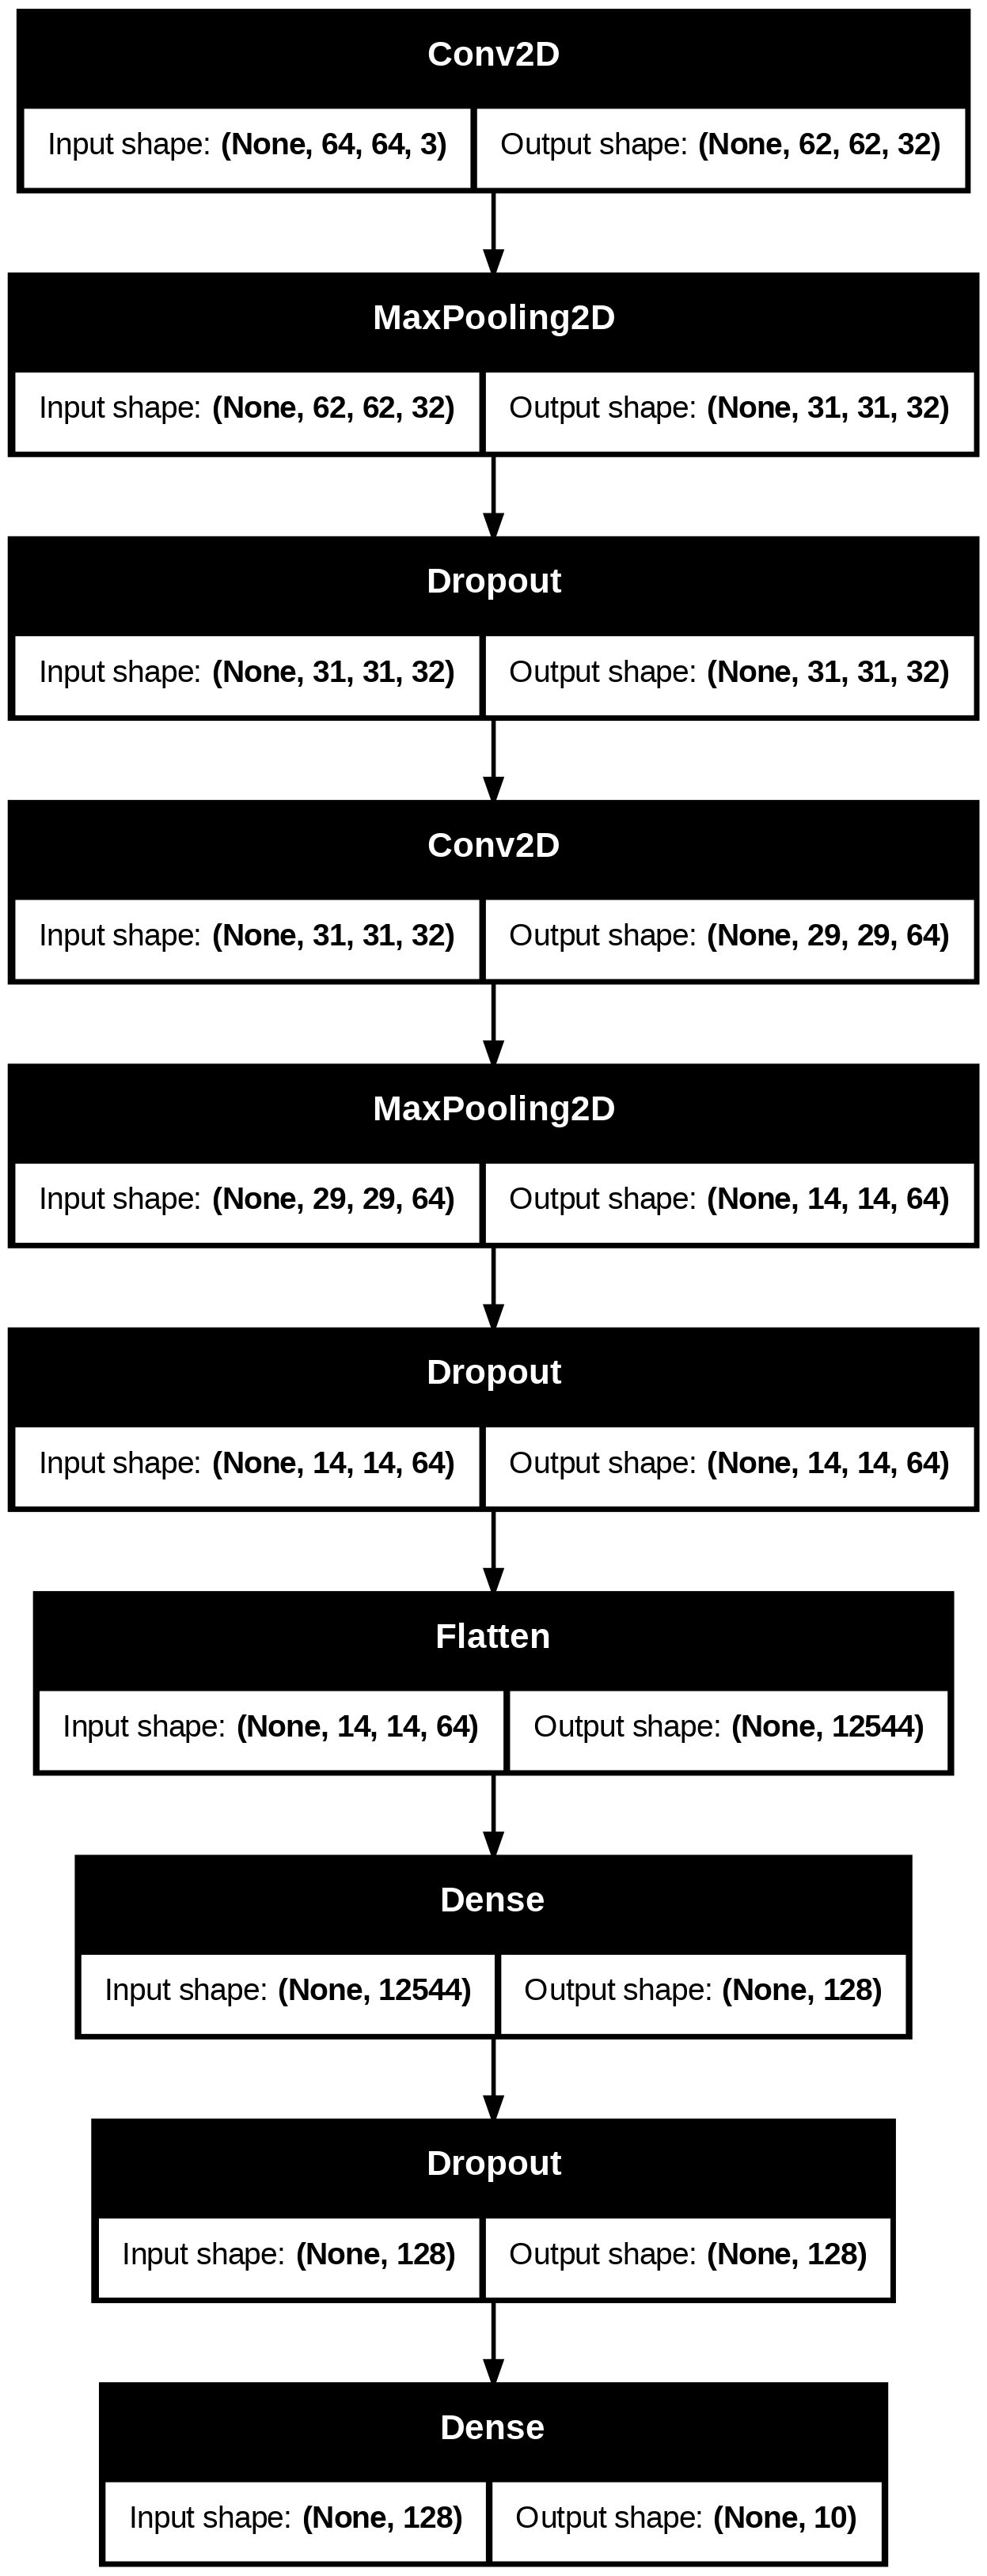

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import LabelEncoder

# one-hot encoding
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

# Reshape the images to (64, 64, 3) for the CNN model
# X_train and X_test need to have the shape (n_samples, 64, 64, 3)
X_train_reshaped = X_train.reshape(-1, 64, 64, 3)
X_test_reshaped = X_test.reshape(-1, 64, 64, 3)

# Model Four: CNN with Conv2D, MaxPooling2D, Dropout, Flatten, Dense
model4 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),  # First convolutional layer with 32 filters
    MaxPooling2D(pool_size=(2, 2)),  # Max pooling layer
    Dropout(0.25),  # Dropout with 25% rate
    Conv2D(64, (3, 3), activation='relu'),  # Second convolutional layer with 64 filters
    MaxPooling2D(pool_size=(2, 2)),  # Max pooling layer
    Dropout(0.25),  # Dropout with 25% rate
    Flatten(),  # Flatten the output for the fully connected layers
    Dense(128, activation='relu'),  # Fully connected layer with 128 neurons
    Dropout(0.5),  # Dropout with 50% rate for the fully connected layers
    Dense(10, activation='softmax')  # Output layer with 10 classes and softmax activation
])

# Compile and train
model4.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history4 = model4.fit(X_train_reshaped, y_train_enc, epochs=10, batch_size=32, validation_data=(X_test_reshaped, y_test_enc))

# Accuracy
test_loss, test_acc = model4.evaluate(X_test_reshaped, y_test_enc)
print(f"Model 4 Test Accuracy: {test_acc:.4f}")

# network stucture
plot_model(model4, to_file='model4_architecture.png', show_shapes=True)


#### 3.2.2 Model Five - VGG16 transform

For the fifth model, I used transfer learning with a pre-trained VGG16 model to improve classification accuracy on the EuroSAT dataset. The VGG16 base was frozen and a custom dense head was added. This approach aimed to leverage features learned from ImageNet. However, the model achieved only 0.74 accuracy, which is lower than my previous custom CNN (0.83). Therefore, the CNN remained the best-performing model due to better task alignment and generalization.

The two classes with the highest misclassification rates are **PermanentCrop** and **Highway**, as shown in the image. For example, PermanentCrop is often confused with HerbaceousVegetation, and Highway is misclassified as River or Residential. These errors likely stem from visual similarities in satellite imagery—fields and vegetation can have overlapping textures, and highways near rivers or urban areas can resemble those categories. To improve performance, possible strategies include using **more domain-specific data augmentation**, incorporating **spatial context via larger input sizes**, or applying **attention mechanisms** to help the model focus on distinguishing features.

Epoch 1/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 416s 3s/step - accuracy: 0.4292 - loss: 1.5682 - val_accuracy: 0.6543 - val_loss: 0.9762
Epoch 2/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 412s 3s/step - accuracy: 0.6381 - loss: 1.0030 - val_accuracy: 0.6911 - val_loss: 0.8677
Epoch 3/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 413s 3s/step - accuracy: 0.6732 - loss: 0.9082 - val_accuracy: 0.7055 - val_loss: 0.8261
Epoch 4/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 449s 4s/step - accuracy: 0.6930 - loss: 0.8556 - val_accuracy: 0.7167 - val_loss: 0.7880
Epoch 5/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 412s 3s/step - accuracy: 0.7021 - loss: 0.8204 - val_accuracy: 0.7210 - val_loss: 0.7727
Epoch 6/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 412s 3s/step - accuracy: 0.7111 - loss: 0.8010 - val_accuracy: 0.7291 - val_loss: 0.7509
Epoch 7/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 450s 4s/step - accuracy: 0.7210 - loss: 0.7771 - val_accuracy: 0.7262 - val_loss: 0.7574
Epoch 8/10
127/127 ━━━━━━━━━━━━━━━━━━━━ 414s 3s/step - accuracy: 0.7323 - loss: 0.7506 - val_accu

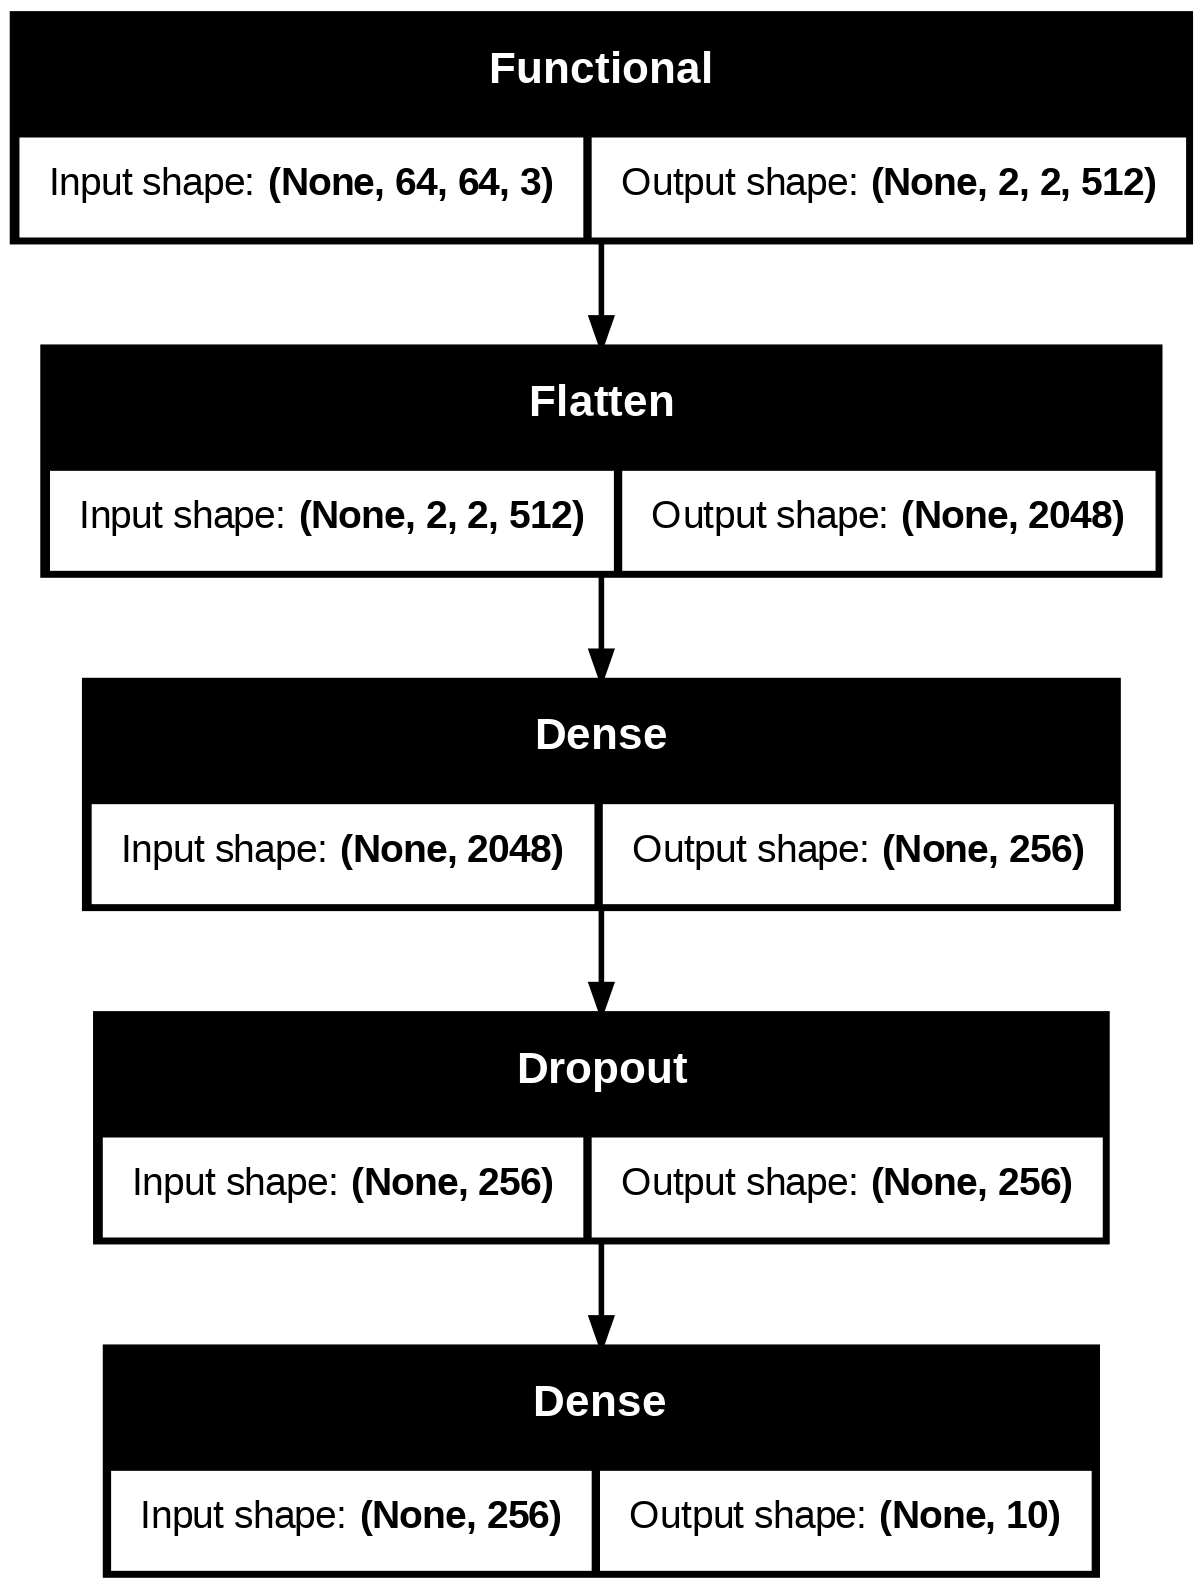

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import LabelEncoder

# one-hot encoding
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

# Reshape the images to (64, 64, 3) for the CNN model (if not already reshaped)
X_train_reshaped = X_train.reshape(-1, 64, 64, 3)
X_test_reshaped = X_test.reshape(-1, 64, 64, 3)

# Load the pre-trained VGG16 model (without the top fully connected layers)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze the layers of the base model (we will not update these during training)
base_model.trainable = False

# Build the custom model on top of VGG16
model5 = Sequential([
    base_model,  # Add the pre-trained VGG16 base model
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile the model
model5.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history5 = model5.fit(X_train_reshaped, y_train_enc, epochs=10, batch_size=256, validation_data=(X_test_reshaped, y_test_enc))

# Evaluate the model on the test data
test_loss, test_acc = model5.evaluate(X_test_reshaped, y_test_enc)
print(f"Model 5 Test Accuracy: {test_acc:.4f}")

# Visualize the model architecture
plot_model(model5, to_file='model5_architecture.png', show_shapes=True)


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Predict the labels for the test set
y_pred = model5.predict(X_test_reshaped)
y_pred_classes = np.argmax(y_pred, axis=1)



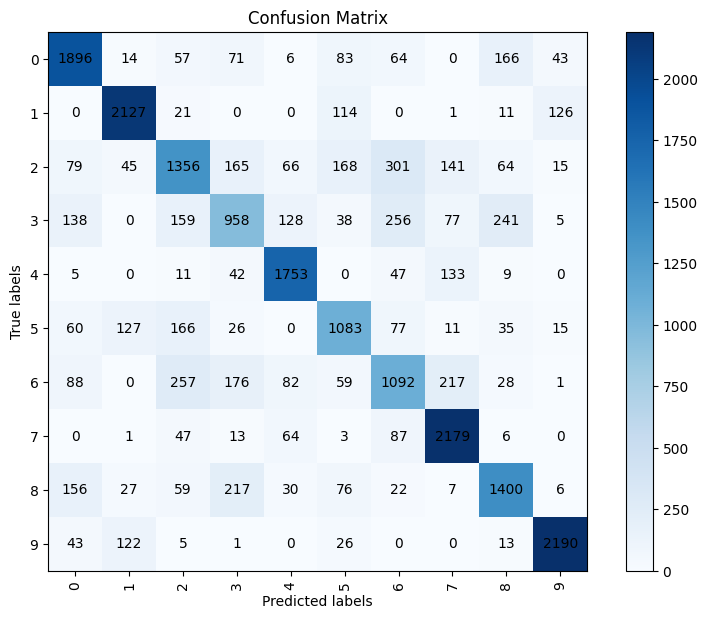

The two classes with the highest labeling errors: PermanentCrop, Highway


In [ ]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_classes)

# Display the confusion matrix
plt.figure(figsize=(10, 7))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(10), encoder.classes_, rotation=90)
plt.yticks(np.arange(10), encoder.classes_)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')

# Loop over the confusion matrix and add the text to display the values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f'{cm[i, j]}', ha='center', va='center', color='black')

plt.show()

# Find the two classes with the highest labeling error
error_rates = cm.diagonal() / cm.sum(axis=1)
error_rates = 1 - error_rates  # Error rate = 1 - accuracy
sorted_classes = np.argsort(error_rates)[-2:]  # Get the indices of the two classes with highest errors
print(f"The two classes with the highest labeling errors: {classes[sorted_classes[0]]}, {classes[sorted_classes[1]]}")


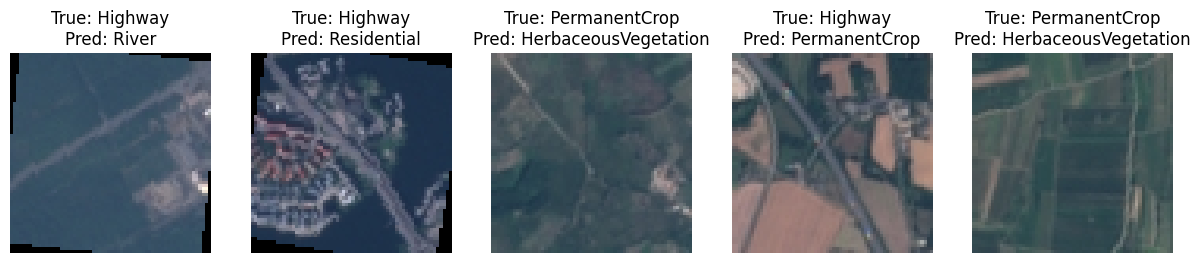

In [ ]:
# Identify misclassified examples for the two classes with the highest error rates
misclassified_indexes = np.where(y_pred_classes != y_test_enc)[0]

# Loop through the two classes with the highest errors
misclassified_images = []
misclassified_labels = []
misclassified_pred_labels = []

for i in misclassified_indexes:
    if y_test_enc[i] == sorted_classes[0] or y_test_enc[i] == sorted_classes[1]:
        X_test_reshaped = X_test.reshape(21600, 3, 64, 64)
        X_test_reshaped = np.transpose(X_test_reshaped, (0, 2, 3, 1))
        misclassified_images.append(X_test_reshaped[i])
        misclassified_labels.append(y_test_enc[i])
        misclassified_pred_labels.append(y_pred_classes[i])

# Show a few misclassified examples
fig, axes = plt.subplots(1, 5, figsize=(15, 15))
for i in range(5):
    axes[i].imshow(misclassified_images[i])
    axes[i].set_title(f"True: {classes[misclassified_labels[i]]}\nPred: {classes[misclassified_pred_labels[i]]}")
    axes[i].axis('off')
plt.show()


In [ ]:
__, test_acc1 = model1.evaluate(X_test_gray, y_test_enc)
__, test_acc2 = model2.evaluate(X_test_gray, y_test_enc)
__, test_acc3 = model3.evaluate(X_test_gray, y_test_enc)
__, test_acc4 = model4.evaluate(X_test_reshaped, y_test_enc)
__, test_acc5 = model5.evaluate(X_test_reshaped, y_test_enc)
print(f"Model 1 Test Accuracy: {test_acc1:.4f}")
print(f"Model 2 Test Accuracy: {test_acc2:.4f}")
print(f"Model 3 Test Accuracy: {test_acc3:.4f}")
print(f"Model 4 Test Accuracy: {test_acc4:.4f}")
print(f"Model 5 Test Accuracy: {test_acc5:.4f}")

Model 1 Test Accuracy: 0.2373
Model 2 Test Accuracy: 0.3773
Model 3 Test Accuracy: 0.1475
Model 4 Test Accuracy: 0.8282
Model 5 Test Accuracy: 0.7423


### 3.3 Multispectral Images

I have downloaded the full-band EuroSAT dataset to my google drive. I applied my best-performing CNN model to multispectral images using bands 2 (Blue), 3 (Green), 4 (Red), 8 (NIR), and 11 (SWIR). Compared to using only RGB bands (2, 3, 4), the classification accuracy improved, demonstrating that additional spectral information can significantly enhance land cover classification. The NIR and SWIR bands provide valuable insights into vegetation health, water content, and soil properties, which are not captured by RGB alone. This richer spectral input allows the model to better distinguish between visually similar classes, such as PermanentCrop and HerbaceousVegetation, leading to improved performance.

In [ ]:
zip_path = "/content/drive/MyDrive/MUSA650/data/EuroSAT_MS.zip"
extract_path = "/content/drive/MyDrive/MUSA650/data/eurosat_ms"

# unzip
with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# view files
tif_files = [os.path.join(dp, f) for dp, dn, filenames in os.walk(extract_path) for f in filenames if f.endswith(".tif")]
print("Total images:", len(tif_files))
print("Example file path:", tif_files[0])

In [ ]:
class EuroSATMultispectralDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(root_dir))  # Ensure that the category order is fixed
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

        for cls in self.classes:
            cls_folder = os.path.join(root_dir, cls)
            for file in os.listdir(cls_folder):
                if file.endswith('.tif'):
                    self.image_paths.append(os.path.join(cls_folder, file))
                    self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        with rasterio.open(image_path) as src:
            image = src.read().astype(np.float32)  # shape: [13, 64, 64]

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return torch.tensor(image), label

In [ ]:
data_dir = "/content/drive/MyDrive/MUSA650/data/eurosat_ms/EuroSAT_MS"
dataset = EuroSATMultispectralDataset(root_dir=data_dir)
classes = dataset.classes

# Print the total number, category, shape and label of a sample
print("Total images:", len(dataset))
print("Classes:", classes)

# view the first sample
sample_img, sample_label = dataset[0]
print("Sample shape:", sample_img.shape)  # torch.Size([13, 64, 64])
print("Sample label:", sample_label)
print("Label name:", dataset.classes[sample_label])


Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Sample shape: torch.Size([13, 64, 64])
Sample label: 0
Label name: AnnualCrop


Data shape: (27000, 64, 64, 5), Labels shape: (27000,)
Training set: (16200, 64, 64, 5), Test set: (10800, 64, 64, 5)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,627,018 (6.21 MB)

...

127/127 ━━━━━━━━━━━━━━━━━━━━ 22s 175ms/step - accuracy: 0.8765 - loss: 0.3603 - val_accuracy: 0.8898 - val_loss: 0.3644
Epoch 21/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 22s 176ms/step - accuracy: 0.8765 - loss: 0.3536 - val_accuracy: 0.8888 - val_loss: 0.3399
Epoch 22/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.8846 - loss: 0.3303 - val_accuracy: 0.8703 - val_loss: 0.4023
Epoch 23/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step - accuracy: 0.8911 - loss: 0.3235 - val_accuracy: 0.8717 - val_loss: 0.4096
Epoch 24/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.8956 - loss: 0.2928

127/127 ━━━━━━━━━━━━━━━━━━━━ 23s 179ms/step - accuracy: 0.8955 - loss: 0.2930 - val_accuracy: 0.8978 - val_loss: 0.3160
Epoch 25/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.9012 - loss: 0.2849

127/127 ━━━━━━━━━━━━━━━━━━━━ 22s 176ms/step - accuracy: 0.9012 - loss: 0.2850 - val_accuracy: 0.9022 - val_loss: 0.3099
Epoch 26/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9019 - loss: 0.2863

127/127 ━━━━━━━━━━━━━━━━━━━━ 23s 179ms/step - accuracy: 0.9019 - loss: 0.2863 - val_accuracy: 0.9041 - val_loss: 0.2948
Epoch 27/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 23s 184ms/step - accuracy: 0.9141 - loss: 0.2475 - val_accuracy: 0.8879 - val_loss: 0.3463
Epoch 28/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 29s 230ms/step - accuracy: 0.9110 - loss: 0.2553 - val_accuracy: 0.8821 - val_loss: 0.3641
Epoch 29/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9040 - loss: 0.2838

127/127 ━━━━━━━━━━━━━━━━━━━━ 30s 236ms/step - accuracy: 0.9041 - loss: 0.2837 - val_accuracy: 0.9125 - val_loss: 0.2749
Epoch 30/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 23s 181ms/step - accuracy: 0.9243 - loss: 0.2206 - val_accuracy: 0.9077 - val_loss: 0.2975
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9075 - loss: 0.2780
Test accuracy: 0.9125


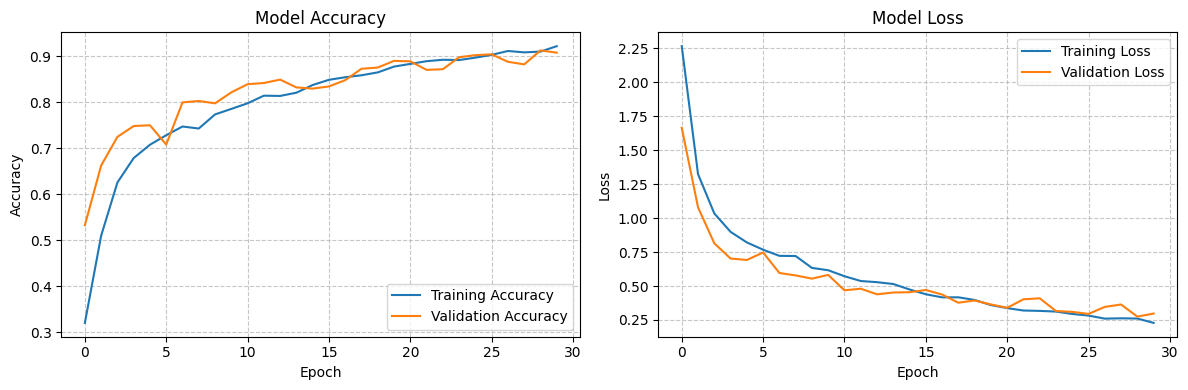

338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


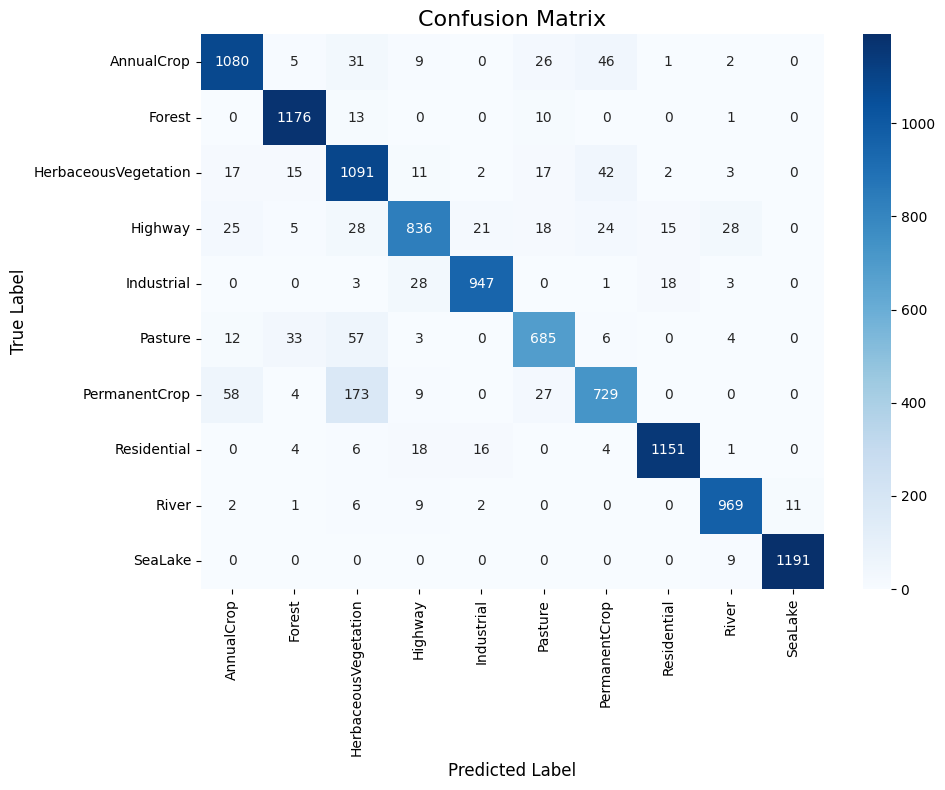

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.90      0.90      0.90      1200
              Forest       0.95      0.98      0.96      1200
HerbaceousVegetation       0.77      0.91      0.84      1200
             Highway       0.91      0.84      0.87      1000
          Industrial       0.96      0.95      0.95      1000
             Pasture       0.87      0.86      0.87       800
       PermanentCrop       0.86      0.73      0.79      1000
         Residential       0.97      0.96      0.96      1200
               River       0.95      0.97      0.96      1000
             SeaLake       0.99      0.99      0.99      1200

            accuracy                           0.91     10800
           macro avg       0.91      0.91      0.91     10800
        weighted avg       0.91      0.91      0.91     10800



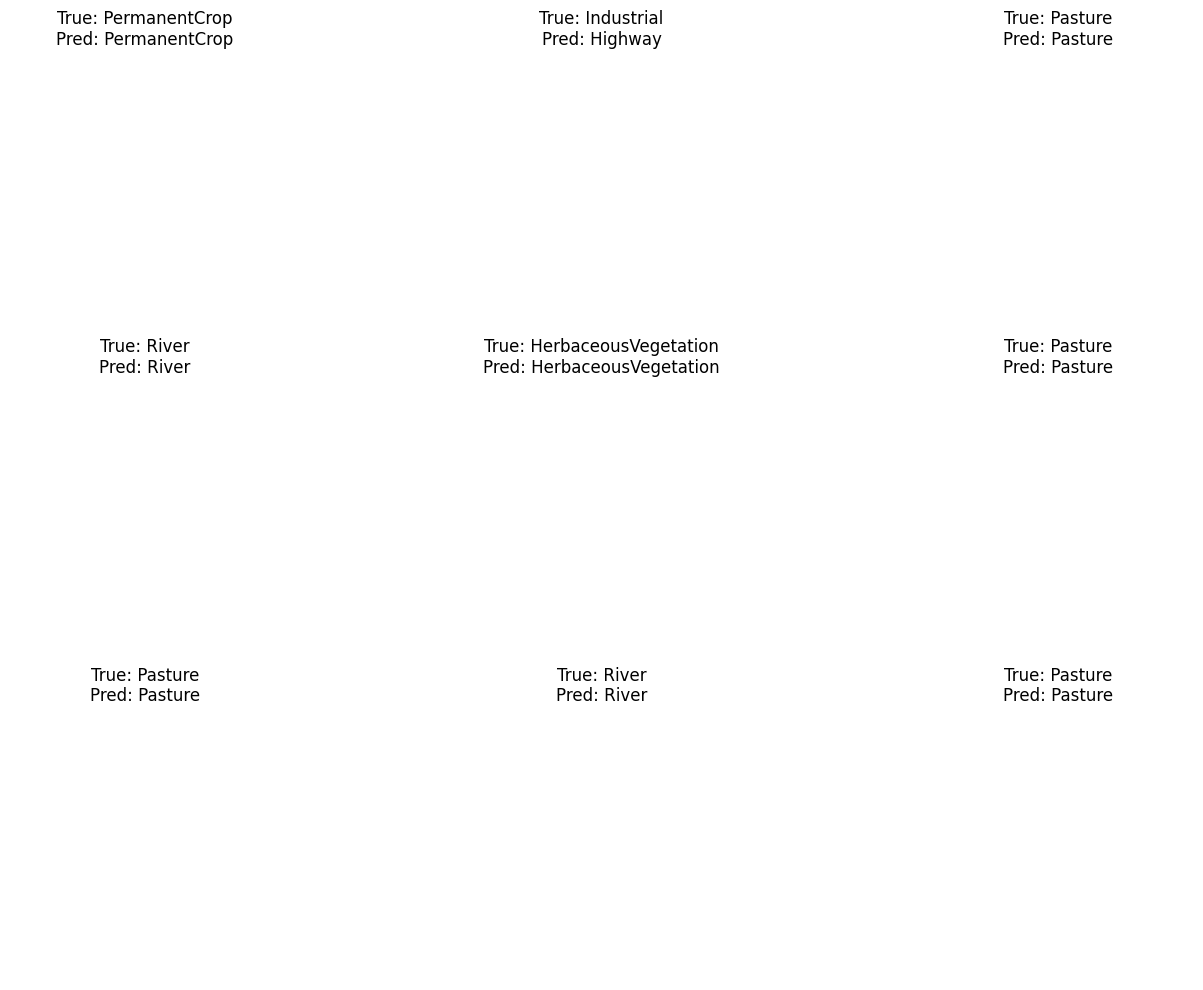

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

#Prepare the dataset - extract the specified band and convert it to Numpy format

def prepare_dataset(dataset, selected_bands=[1, 2, 3, 7, 10]):  # Corresponding bands 2, 3, 4, 8, 11 (index starts from 0)
    X = []
    y = []

    for i in range(len(dataset)):
        img, label = dataset[i]
        img_selected = img[selected_bands].numpy()
        # Transpose to (H, W, C) format, suitable for TensorFlow
        img_selected = np.transpose(img_selected, (1, 2, 0))
        X.append(img_selected)
        y.append(label)

    return np.array(X), np.array(y)

X, y = prepare_dataset(dataset)
print(f"Data shape: {X.shape}, Labels shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=650, stratify=y)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# data normalization
X_train = X_train / 255.0
X_test = X_test / 255.0

# define model
model6 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 5)),  # 5个波段
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')  # 10 classes
])

model6.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model6.summary()

callbacks = [
    ModelCheckpoint('best_model6.h5', save_best_only=True, monitor='val_accuracy'),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

# train model
history = model6.fit(
    X_train, y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

# evaluate
test_loss, test_acc = model6.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# visualize train history
plt.figure(figsize=(12, 4))

# accuracy graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# loss function subgraph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# predict
y_pred = model6.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# plot confusiono matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=dataset.classes))

# # visualize some samples
# plt.figure(figsize=(15, 10))
# for i in range(9):
#     plt.subplot(3, 3, i+1)
#     # Display RGB composite image (channels 1,2,3 correspond to bands 2,3,4)
#     rgb_img = X_test[i][:,:,:3]
#     plt.imshow(rgb_img)
#     true_label = dataset.classes[y_test[i]]
#     pred_label = dataset.classes[y_pred_classes[i]]
#     plt.title(f"True: {true_label}\nPred: {pred_label}")
#     plt.axis('off')
# plt.tight_layout()
# plt.show()

## 4. Reflection Questions

One important takeaway from tuning model parameters is that there is no universally optimal value—settings are often task-dependent. While extremely inappropriate values can degrade performance, most parameters fall within a workable range. Ultimately, the most reliable way to decide is to evaluate performance on validation or test data, which underscores the importance of trying multiple configurations to find what works best.

Extending the number of training epochs usually enhances performance, but only up to a certain point. After that, gains become negligible or even negative due to overfitting. In addition, longer training increases computational demands, which may not always be feasible under hardware constraints.

Dropout was useful for improving generalization and limiting overfitting, especially in deeper or more complex architectures. However, in relatively shallow networks or when overused, it introduced underfitting issues. This was particularly evident in simpler models like Model 3.

The most significant obstacle I encountered was limited processing capability. When experimenting with CNN and VGG16, the training time was really long due to model size and complexity.

This project reinforced several broader lessons: enhanced compute allows for more experimentation and faster results; careful data preprocessing greatly influences outcomes; and regularization techniques such as Dropout can be powerful tools if applied with proper understanding of model structure and task complexity.